In [35]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import os
import statsmodels.api as sm
import numpy as np
import sys
sys.path.append("..")  # db_config.py lives in the repo root
from db_config import read_sql

TRAIN_END = "2019-12-01"
TEST_START = "2020-01-01"
OUTCOME = "dlq90" #Either dlq30 or dlq90
LAGS ={"dlq30":4, "dlq90":5}
LAG_UR, LAG_HPI = LAGS[OUTCOME],7 
EXCLUDE = range(2005,2008)
VARS = ["ur_lag", "hpi_lag"]
LOG_FILE = "model_log.csv"
PERIODS = {"Covid mid (2020-2021)": ("2020-01-01", "2021-06-01"), "H2 2022": ("2022-07-01", "2022-12-01"), "2023 On": ("2023-01-01", None)}



dlq = read_sql("SELECT * FROM sf_state_month")
dlq["report_date"] = pd.to_datetime(dlq["reporting_date"])
dlq["dlq30_rate"] = dlq["dlq30"] / dlq["loan_count"] * 100
dlq["dlq90_rate"] = dlq["dlq90"] / dlq["loan_count"] * 100

nat = dlq.groupby("report_date")[["loan_count","dlq30","dlq90"]].sum()
nat["dlq30_rate"] = nat["dlq30"] / nat["loan_count"] * 100

print(dlq.shape, dlq["property_state"].nunique())
print(nat.loc["2014-01":"2014-06", ["loan_count","dlq30_rate"]])

econ = read_sql(""" SELECT report_date, state, unemployment_rate, hpi_index FROM economic_indicators WHERE report_date >= '2002-01-01'""")
econ['report_date'] = pd.to_datetime(econ['report_date'])

m = dlq.merge(econ, left_on=["report_date", "property_state"], right_on=["report_date", "state"], how="left")

m["ur_x_loans"] = m["unemployment_rate"] * m["loan_count"]

ur = m.groupby("report_date", as_index=False)[["ur_x_loans", "loan_count"]].sum()
ur["unemployment_rate"] = ur["ur_x_loans"]/ur["loan_count"]

plot_df = nat.merge(ur[["report_date", "unemployment_rate"]], on="report_date")

C:\Users\H59045\AppData\Local\Temp\1\ipykernel_19364\3860242262.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dlq = pd.read_sql("SELECT * FROM sf_state_month", conn)


(150890, 9) 54
             loan_count  dlq30_rate
report_date                        
2014-01-01       446233    6.138945
2014-02-01       577829    4.792421
2014-03-01       715881    3.643762
2014-04-01       749670    3.429642
2014-05-01       742493    3.437878
2014-06-01       734820    3.468877


C:\Users\H59045\AppData\Local\Temp\1\ipykernel_19364\3860242262.py:34: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  econ = pd.read_sql(""" SELECT report_date, state, unemployment_rate, hpi_index FROM economic_indicators WHERE report_date >= '2002-01-01'""", conn)


In [36]:
dlq["report_date"] = pd.to_datetime(dlq["reporting_date"])
econ["report_date"] = pd.to_datetime(econ["report_date"])

clean = dlq[~dlq["orig_year"].isin(EXCLUDE)]
st = (clean.groupby(["property_state", "report_date"], as_index=False)
           [["loan_count", "dlq30", "dlq90"]].sum())

st = (st.merge(econ, left_on=["property_state", "report_date"],
               right_on=["state", "report_date"], how="inner")
        .sort_values(["property_state", "report_date"]))




by = lambda c: st.groupby("property_state")[c]
st["dlq_rate"] = st[OUTCOME] / st["loan_count"] * 100
st["dlq_chg"] = by("dlq_rate").diff(12)
st["ur_chg"] = by("unemployment_rate").diff(12)
st["hpi_chg"] = by("hpi_index").pct_change(12, fill_method=None) * 100

st["ur_lag"] = by("ur_chg").shift(LAG_UR)
st["hpi_lag"] = by("hpi_chg").shift(LAG_HPI)


In [37]:
cols = ["dlq_chg"] + VARS
train = st[st["report_date"] <= TRAIN_END].dropna(subset=cols)

model = sm.WLS(train["dlq_chg"], sm.add_constant(train[VARS]),
               weights=train["loan_count"]).fit(
    cov_type="cluster", cov_kwds={"groups": train["property_state"]})
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                dlq_chg   R-squared:                       0.303
Model:                            WLS   Adj. R-squared:                  0.303
Method:                 Least Squares   F-statistic:                     66.15
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           9.00e-15
Time:                        14:36:54   Log-Likelihood:                -14033.
No. Observations:               10032   AIC:                         2.807e+04
Df Residuals:                   10029   BIC:                         2.809e+04
Df Model:                           2                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0487      0.022     -2.230      0.0

rmse_Covid mid (2020-2021)     1.358
naive_Covid mid (2020-2021)    2.297
rmse_H2 2022                   0.468
naive_H2 2022                  1.435
rmse_2023 On                   0.211
naive_2023 On                  0.355
dtype: float64


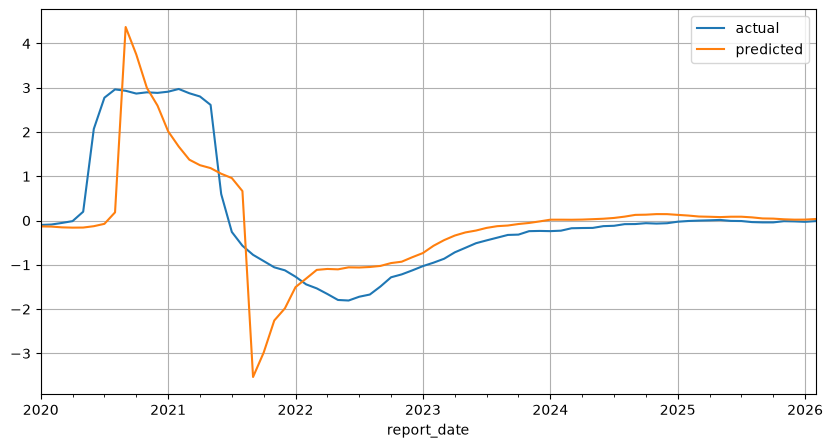

In [38]:
test = st[st["report_date"] >= TEST_START].dropna(subset=cols).copy()
test["pred"] = model.predict(sm.add_constant(test[VARS], has_constant="add"))

test["w_act"] = test["dlq_chg"] * test["loan_count"]
test["w_pred"] = test["pred"] * test["loan_count"]
cmp = test.groupby("report_date")[["w_act", "w_pred", "loan_count"]].sum()
cmp["actual"] = cmp["w_act"] / cmp["loan_count"]
cmp["predicted"] = cmp["w_pred"] / cmp["loan_count"]

rmse = lambda e: np.sqrt((e ** 2).mean())
scores = {}
for name, (s, e) in PERIODS.items():
    p = cmp.loc[s:e]
    scores[f"rmse_{name}"] = rmse(p["predicted"] - p["actual"])
    scores[f"naive_{name}"] = rmse(p["actual"])
print(pd.Series(scores).round(3))

cmp[["actual", "predicted"]].plot(figsize=(10, 5), grid=True)
plt.show()


In [5]:
row = {
    "run_date": pd.Timestamp.today().date(),
    "vintages": ",".join(map(str, sorted(clean["orig_year"].unique()))),
    "n_train": int(model.nobs),
    "r2": model.rsquared,
    **{f"{v}_beta": model.params[v] for v in VARS},
    **{f"{v}_se": model.bse[v] for v in VARS},
    **scores,
}
pd.DataFrame([row]).to_csv(LOG_FILE, mode="a",
                           header=not os.path.exists(LOG_FILE), index=False)


In [33]:
for lag in [3, 5, 7, 8]:
    st["ur_lag"] = st.groupby("property_state")["ur_chg"].shift(lag)
    tr = st[st["report_date"] <= TRAIN_END].dropna(subset=["dlq_chg"] + VARS)
    m_ = sm.WLS(tr["dlq_chg"], sm.add_constant(tr[VARS]),
                weights=tr["loan_count"]).fit(
        cov_type="cluster", cov_kwds={"groups": tr["property_state"]})
    print(f"lag {lag}: beta {m_.params['ur_lag']:.3f}, se {m_.bse['ur_lag']:.3f}, r2 {m_.rsquared:.3f}")


lag 3: beta 0.414, se 0.036, r2 0.317
lag 5: beta 0.407, se 0.035, r2 0.303
lag 7: beta 0.378, se 0.035, r2 0.269
lag 8: beta 0.356, se 0.035, r2 0.248
